In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('..')
from src.models.clustering import (
    build_duplicate_graph,
    build_clusters_from_graph,
    attach_clusters_to_records,
    compute_cluster_stats,
    get_large_clusters,
    get_suspicious_clusters,
    add_canonical_names,
    filter_edges_for_clustering,
)

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_parquet(
    "../data/processed/processed_dataset.parquet"
)

scored_pairs = pd.read_parquet(
    "../data/processed/scored_pairs_sample.parquet"
)

print(f"Records: {len(df):,}")
print(f"Scored pairs: {len(scored_pairs):,}")

Records: 3,653,581
Scored pairs: 2,865,301


In [3]:
# ============================================================
# BASELINE DUPLICATE PAIRS BEFORE EDGE FILTERING
# ============================================================

score_threshold = 0.95

duplicate_pairs_before = scored_pairs[
    scored_pairs["duplicate_score"] >= score_threshold
].copy()

print("=" * 60)
print("BEFORE EDGE FILTERING")
print("=" * 60)

print(f"Score threshold: {score_threshold}")
print(f"Duplicate pairs before: {len(duplicate_pairs_before):,}")

display(
    duplicate_pairs_before[
        [
            "party_name_1",
            "party_name_2",
            "name_latin_1",
            "name_latin_2",
            "duplicate_score",
            "token_jaccard",
            "length_diff",
            "core_token_set_ratio",
            "has_garbage_entity",
        ]
    ]
    .sort_values("duplicate_score", ascending=False)
    .head(30)
)

BEFORE EDGE FILTERING
Score threshold: 0.95
Duplicate pairs before: 253,772


,party_name_1,party_name_2,name_latin_1,name_latin_2,duplicate_score,token_jaccard,length_diff,core_token_set_ratio,has_garbage_entity
1313669,Համադ Բինխալիֆ Բինհամադ Ալ-Թանի,Համադ Բինխալիֆա Բինհամադ Ալ-Թանի,hamad binkhalif binhamad al tani,hamad binkhalifa binhamad al tani,1.000000,0.666667,1,98.461538,0
1313675,Համադ Բինխալիֆա Բինհամադ Ալ-Թանի,Համադ Բինխալիֆ Բինհամադ Ալ-Թանի,hamad binkhalifa binhamad al tani,hamad binkhalif binhamad al tani,1.000000,0.666667,1,98.461538,0
1313676,Համադ Բինխալիֆա Բինհամադ Ալ-Թանի,Համադ Բինխալիֆ Բինհամադ Ալ-Թանի,hamad binkhalifa binhamad al tani,hamad binkhalif binhamad al tani,1.000000,0.666667,1,98.461538,0
1313664,Համադ Բինխալիֆ Բինհամադ Ալ-Թանի,Համադ Բինխալիֆա Բինհամադ Ալ-Թանի,hamad binkhalif binhamad al tani,hamad binkhalifa binhamad al tani,1.000000,0.666667,1,98.461538,0
1313674,Համադ Բինխալիֆա Բինհամադ Ալ-Թանի,Համադ Բինխալիֆ Բինհամադ Ալ-Թանի,hamad binkhalifa binhamad al tani,hamad binkhalif binhamad al tani,1.000000,0.666667,1,98.461538,0
1849272,ՄՈՐԻՑ ՋՀՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,ՄՈՐԻՑ ՋՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,morits jhonatan hieronimous hill,morits jonatan hieronimous hill,1.000000,0.600000,1,98.412698,0
1849271,ՄՈՐԻՑ ՋՀՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,ՄՈՐԻՑ ՋՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,morits jhonatan hieronimous hill,morits jonatan hieronimous hill,1.000000,0.600000,1,98.412698,0
1849270,ՄՈՐԻՑ ՋՀՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,ՄՈՐԻՑ ՋՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,morits jhonatan hieronimous hill,morits jonatan hieronimous hill,1.000000,0.600000,1,98.412698,0
1849269,ՄՈՐԻՑ ՋՀՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,ՄՈՐԻՑ ՋՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,morits jhonatan hieronimous hill,morits jonatan hieronimous hill,1.000000,0.600000,1,98.412698,0
1849268,ՄՈՐԻՑ ՋՀՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,ՄՈՐԻՑ ՋՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,morits jhonatan hieronimous hill,morits jonatan hieronimous hill,1.000000,0.600000,1,98.412698,0


In [4]:
# ============================================================
# APPLY EDGE FILTERING
# ============================================================

duplicate_pairs_after = filter_edges_for_clustering(
    scored_pairs=scored_pairs,
    score_threshold=0.95,
    strict_score_threshold=0.995,
)

print("=" * 60)
print("AFTER EDGE FILTERING")
print("=" * 60)

print(f"Duplicate pairs after: {len(duplicate_pairs_after):,}")
print(
    f"Removed pairs: {len(duplicate_pairs_before) - len(duplicate_pairs_after):,}"
)
print(
    f"Remaining ratio: {len(duplicate_pairs_after) / len(duplicate_pairs_before) * 100:.2f}%"
)

display(
    duplicate_pairs_after[
        [
            "party_name_1",
            "party_name_2",
            "name_latin_1",
            "name_latin_2",
            "duplicate_score",
            "token_jaccard",
            "length_diff",
            "core_token_set_ratio",
            "has_garbage_entity",
        ]
    ]
    .sort_values("duplicate_score", ascending=False)
    .head(30)
)

AFTER EDGE FILTERING
Duplicate pairs after: 253,413
Removed pairs: 359
Remaining ratio: 99.86%


,party_name_1,party_name_2,name_latin_1,name_latin_2,duplicate_score,token_jaccard,length_diff,core_token_set_ratio,has_garbage_entity
1313664,Համադ Բինխալիֆ Բինհամադ Ալ-Թանի,Համադ Բինխալիֆա Բինհամադ Ալ-Թանի,hamad binkhalif binhamad al tani,hamad binkhalifa binhamad al tani,1.000000,0.666667,1,98.461538,0
1313676,Համադ Բինխալիֆա Բինհամադ Ալ-Թանի,Համադ Բինխալիֆ Բինհամադ Ալ-Թանի,hamad binkhalifa binhamad al tani,hamad binkhalif binhamad al tani,1.000000,0.666667,1,98.461538,0
1313675,Համադ Բինխալիֆա Բինհամադ Ալ-Թանի,Համադ Բինխալիֆ Բինհամադ Ալ-Թանի,hamad binkhalifa binhamad al tani,hamad binkhalif binhamad al tani,1.000000,0.666667,1,98.461538,0
1313674,Համադ Բինխալիֆա Բինհամադ Ալ-Թանի,Համադ Բինխալիֆ Բինհամադ Ալ-Թանի,hamad binkhalifa binhamad al tani,hamad binkhalif binhamad al tani,1.000000,0.666667,1,98.461538,0
1313669,Համադ Բինխալիֆ Բինհամադ Ալ-Թանի,Համադ Բինխալիֆա Բինհամադ Ալ-Թանի,hamad binkhalif binhamad al tani,hamad binkhalifa binhamad al tani,1.000000,0.666667,1,98.461538,0
1849271,ՄՈՐԻՑ ՋՀՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,ՄՈՐԻՑ ՋՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,morits jhonatan hieronimous hill,morits jonatan hieronimous hill,1.000000,0.600000,1,98.412698,0
1849272,ՄՈՐԻՑ ՋՀՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,ՄՈՐԻՑ ՋՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,morits jhonatan hieronimous hill,morits jonatan hieronimous hill,1.000000,0.600000,1,98.412698,0
1849270,ՄՈՐԻՑ ՋՀՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,ՄՈՐԻՑ ՋՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,morits jhonatan hieronimous hill,morits jonatan hieronimous hill,1.000000,0.600000,1,98.412698,0
1849268,ՄՈՐԻՑ ՋՀՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,ՄՈՐԻՑ ՋՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,morits jhonatan hieronimous hill,morits jonatan hieronimous hill,1.000000,0.600000,1,98.412698,0
1849269,ՄՈՐԻՑ ՋՀՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,ՄՈՐԻՑ ՋՈՆԱԹԱՆ ՀԻԵՐՈՆԻՄՈՒՍ ՀԻԼԼ,morits jhonatan hieronimous hill,morits jonatan hieronimous hill,1.000000,0.600000,1,98.412698,0


In [5]:
# ============================================================
# BUILD CLUSTERS HELPER
# ============================================================

def build_clustered_sample(scored_pairs_input, threshold=0.95):
    graph = build_duplicate_graph(
        predicted_pairs=scored_pairs_input,
        score_col="duplicate_score",
        threshold=threshold,
    )

    clusters = build_clusters_from_graph(graph)

    sample_indices = (
        set(scored_pairs_input["idx1"])
        |
        set(scored_pairs_input["idx2"])
    )

    df_sample = df.loc[list(sample_indices)].copy()

    clustered_df = attach_clusters_to_records(
        df=df_sample,
        clusters=clusters,
    )

    clustered_df = add_canonical_names(
        clustered_df,
        name_col="name_latin",
    )

    cluster_stats = compute_cluster_stats(clustered_df)

    return graph, clusters, clustered_df, cluster_stats

In [6]:
# ============================================================
# CLUSTERING BEFORE EDGE FILTERING
# ============================================================

graph_before, clusters_before, clustered_before, stats_before = build_clustered_sample(
    duplicate_pairs_before,
    threshold=0.95,
)

print("=" * 60)
print("CLUSTERING BEFORE EDGE FILTERING")
print("=" * 60)

print(f"Graph nodes: {graph_before.number_of_nodes():,}")
print(f"Graph edges: {graph_before.number_of_edges():,}")
print(f"Clusters found: {clusters_before['entity_id'].nunique():,}")
print(f"Clustered records: {len(clustered_before):,}")
print(f"Total entities: {len(stats_before):,}")
print(f"Max cluster size: {stats_before['cluster_size'].max():,}")

large_before = get_large_clusters(
    stats_before,
    min_size=20,
)

suspicious_before = get_suspicious_clusters(
    stats_before,
    max_unique_names=5,
    max_unique_countries=3,
)

print(f"Large clusters: {len(large_before):,}")
print(f"Suspicious clusters: {len(suspicious_before):,}")

CLUSTERING BEFORE EDGE FILTERING
Graph nodes: 19,738
Graph edges: 253,772
Clusters found: 6,068
Clustered records: 19,738
Total entities: 6,068
Max cluster size: 369
Large clusters: 54
Suspicious clusters: 2


In [7]:
# ============================================================
# CLUSTERING AFTER EDGE FILTERING
# ============================================================

graph_after, clusters_after, clustered_after, stats_after = build_clustered_sample(
    duplicate_pairs_after,
    threshold=0.95,
)

print("=" * 60)
print("CLUSTERING AFTER EDGE FILTERING")
print("=" * 60)

print(f"Graph nodes: {graph_after.number_of_nodes():,}")
print(f"Graph edges: {graph_after.number_of_edges():,}")
print(f"Clusters found: {clusters_after['entity_id'].nunique():,}")
print(f"Clustered records: {len(clustered_after):,}")
print(f"Total entities: {len(stats_after):,}")
print(f"Max cluster size: {stats_after['cluster_size'].max():,}")

large_after = get_large_clusters(
    stats_after,
    min_size=20,
)

suspicious_after = get_suspicious_clusters(
    stats_after,
    max_unique_names=5,
    max_unique_countries=3,
)

print(f"Large clusters: {len(large_after):,}")
print(f"Suspicious clusters: {len(suspicious_after):,}")

CLUSTERING AFTER EDGE FILTERING
Graph nodes: 19,396
Graph edges: 253,413
Clusters found: 5,953
Clustered records: 19,396
Total entities: 5,953
Max cluster size: 369
Large clusters: 54
Suspicious clusters: 0


In [8]:
# ============================================================
# BEFORE / AFTER COMPARISON
# ============================================================

comparison = pd.DataFrame(
    [
        {
            "stage": "before_edge_filtering",
            "duplicate_pairs": len(duplicate_pairs_before),
            "graph_nodes": graph_before.number_of_nodes(),
            "graph_edges": graph_before.number_of_edges(),
            "clusters_found": clusters_before["entity_id"].nunique(),
            "total_entities": len(stats_before),
            "max_cluster_size": stats_before["cluster_size"].max(),
            "large_clusters": len(large_before),
            "suspicious_clusters": len(suspicious_before),
        },
        {
            "stage": "after_edge_filtering",
            "duplicate_pairs": len(duplicate_pairs_after),
            "graph_nodes": graph_after.number_of_nodes(),
            "graph_edges": graph_after.number_of_edges(),
            "clusters_found": clusters_after["entity_id"].nunique(),
            "total_entities": len(stats_after),
            "max_cluster_size": stats_after["cluster_size"].max(),
            "large_clusters": len(large_after),
            "suspicious_clusters": len(suspicious_after),
        },
    ]
)

display(comparison)

,stage,duplicate_pairs,graph_nodes,graph_edges,clusters_found,total_entities,max_cluster_size,large_clusters,suspicious_clusters
0,before_edge_filtering,253772,19738,253772,6068,6068,369,54,2
1,after_edge_filtering,253413,19396,253413,5953,5953,369,54,0


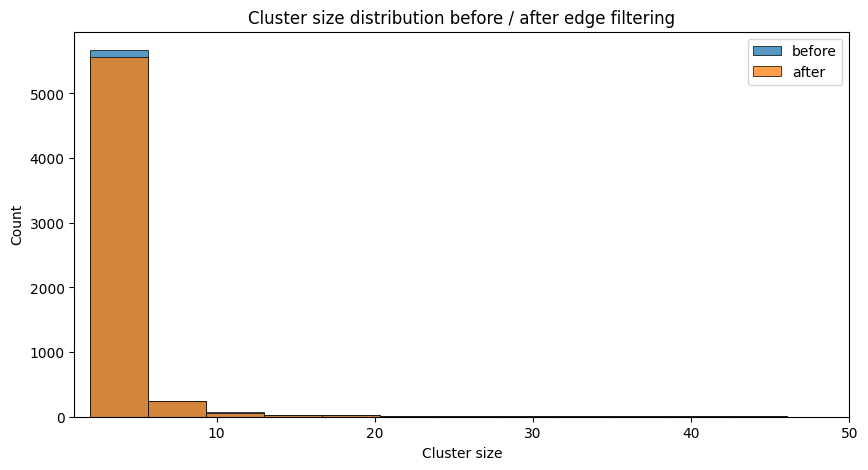

In [9]:
# ============================================================
# CLUSTER SIZE DISTRIBUTION BEFORE / AFTER
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    stats_before["cluster_size"],
    bins=100,
    label="before",
    color=None,
)

sns.histplot(
    stats_after["cluster_size"],
    bins=100,
    label="after",
    color=None,
)

plt.xlim(1, 50)
plt.title("Cluster size distribution before / after edge filtering")
plt.xlabel("Cluster size")
plt.ylabel("Count")
plt.legend()

plt.show()

In [10]:
# ============================================================
# INSPECT SUSPICIOUS CLUSTERS BEFORE
# ============================================================

print("=" * 80)
print("SUSPICIOUS CLUSTERS BEFORE")
print("=" * 80)

display(
    suspicious_before.head(20)
)

SUSPICIOUS CLUSTERS BEFORE


,entity_id,cluster_size,unique_names,unique_countries,unique_scripts,unique_relation_kinds,unique_companies
892,entity_00000892,12,10,1,1,3,11
3145,entity_00003145,7,6,1,1,1,7


In [11]:
# ============================================================
# INSPECT SUSPICIOUS CLUSTERS AFTER
# ============================================================

print("=" * 80)
print("SUSPICIOUS CLUSTERS AFTER")
print("=" * 80)

display(
    suspicious_after.head(20)
)

SUSPICIOUS CLUSTERS AFTER


,entity_id,cluster_size,unique_names,unique_countries,unique_scripts,unique_relation_kinds,unique_companies


In [12]:
# ============================================================
# DETAILED INSPECTION OF SUSPICIOUS CLUSTERS AFTER
# ============================================================

suspicious_entity_ids = suspicious_after["entity_id"].head(5).tolist()

for entity_id in suspicious_entity_ids:
    print("=" * 80)
    print(f"entity_id: {entity_id}")

    subset = clustered_after[
        clustered_after["entity_id"] == entity_id
    ]

    print(f"Cluster size: {len(subset):,}")
    print(f"Canonical name: {subset['canonical_name'].iloc[0]}")
    print(f"Unique names: {subset['name_latin'].nunique()}")
    print(f"Unique countries: {subset['country'].nunique()}")

    display(
        subset[
            [
                "party_name",
                "name_latin",
                "country",
                "relation_kind",
                "relation_role",
                "company_name_norm",
            ]
        ]
        .drop_duplicates()
        .head(50)
    )

In [13]:
# ============================================================
# CHECK MONGOLIAN CHAINING CASE
# ============================================================

target_terms = [
    "batbayar",
    "ganbayar",
    "enhbayar",
    "anhbayar",
    "monhbaatar",
]

mask = clustered_after["name_latin"].fillna("").apply(
    lambda x: any(term in x for term in target_terms)
)

mongolian_case = clustered_after[mask].copy()

print(f"Records found: {len(mongolian_case):,}")

display(
    mongolian_case[
        [
            "entity_id",
            "cluster_size",
            "party_name",
            "name_latin",
            "country",
            "canonical_name",
        ]
    ]
    .sort_values(["cluster_size", "entity_id"], ascending=False)
    .head(100)
)

Records found: 270


,entity_id,cluster_size,party_name,name_latin,country,canonical_name
494,entity_00000888,5,Анхбаяр Батбаяр,anhbayar batbayar,mng,batbayar enhbayar
6711,entity_00000888,5,Батбаяр Энхбаяр,batbayar enhbayar,mng,batbayar enhbayar
13389,entity_00000888,5,Батбаяр Анхбаяр,batbayar anhbayar,mng,batbayar enhbayar
17613,entity_00000888,5,Батбаяр Энхбаяр,batbayar enhbayar,mng,batbayar enhbayar
18964,entity_00000888,5,Энхбаяр Батбаяр,enhbayar batbayar,mng,batbayar enhbayar
...,...,...,...,...,...,...
1187,entity_00005612,2,Энхбаяр Номинэрдэнэ,enhbayar nominerdene,mng,enhbayar nominerdene
10795,entity_00005612,2,Номинэрдэнэ Энхбаяр,nominerdene enhbayar,mng,enhbayar nominerdene
14246,entity_00005611,2,нацагдорж энхбаяр,natsagdorzh enhbayar,mng,natsagdorzh enhbayar
15997,entity_00005611,2,Энхбаяр Нацагдорж,enhbayar natsagdorzh,mng,natsagdorzh enhbayar


In [14]:
# ============================================================
# SAVE FILTERED CLUSTERING RESULTS
# ============================================================

duplicate_pairs_after.to_parquet(
    "../data/processed/duplicate_pairs_filtered_sample.parquet",
    index=False,
)

clustered_after.to_parquet(
    "../data/processed/clustered_sample_filtered.parquet",
    index=False,
)

stats_after.to_parquet(
    "../data/processed/cluster_stats_sample_filtered.parquet",
    index=False,
)

comparison.to_parquet(
    "../data/processed/edge_filtering_comparison.parquet",
    index=False,
)

print("Saved:")
print("../data/processed/duplicate_pairs_filtered_sample.parquet")
print("../data/processed/clustered_sample_filtered.parquet")
print("../data/processed/cluster_stats_sample_filtered.parquet")
print("../data/processed/edge_filtering_comparison.parquet")

Saved:
../data/processed/duplicate_pairs_filtered_sample.parquet
../data/processed/clustered_sample_filtered.parquet
../data/processed/cluster_stats_sample_filtered.parquet
../data/processed/edge_filtering_comparison.parquet


## Вывод по edge filtering

После первичной кластеризации были обнаружены цепочные ошибки, когда разные сущности объединялись в один кластер через последовательность похожих пар.

После фильтрации ребер количество подозрительных кластеров снизилось с 2 до 0. При этом количество ребер уменьшилось незначительно: с 253 772 до 253 413. Это означает, что фильтрация убрала в основном слабые и опасные связи, не разрушив основную структуру дублей.

Отдельно выявлен сложный случай с короткими монгольскими именами из двух токенов. Такие имена требуют более строгих правил кластеризации, потому что перестановка токенов может ошибочно объединять разных людей.